# Assignment 8: Building a Variational Autoencoder and Visualising Its Latent Space

**Objective:** To understand how a Variational Autoencoder (VAE) learns a structured latent space by training on the MNIST dataset and visualising the 2D latent representations.

## Step 1: Importing Libraries

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

## Step 2: Loading MNIST Dataset

In [3]:
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False
)

print(f"Training samples : {len(train_dataset)}")
print(f"Testing samples  : {len(test_dataset)}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 451kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.87MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.2MB/s]

Training samples : 60000
Testing samples  : 10000


## Step 3: Displaying the MNIST Dataset

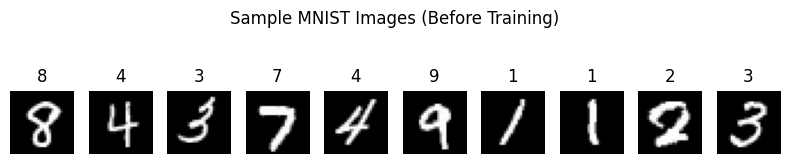

In [4]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(8, 2))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(images[i].squeeze().numpy(), cmap='gray')
    plt.title(str(labels[i].item()))
    plt.axis('off')
plt.suptitle('Sample MNIST Images (Before Training)')
plt.tight_layout()
plt.show()

## Step 4: Normal Autoencoder Architecture

A standard Autoencoder compresses the input image into a latent vector (encoder) and then reconstructs it back (decoder). The activation function used in the final layer is Sigmoid since pixel values are in the range [0, 1].

In [5]:
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, 2)       # latent space of 2 dimensions
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(2, 64),
            nn.ReLU(),
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Sigmoid()           # output in [0, 1] to match pixel values
        )

    def forward(self, x):
        x = x.view(-1, 784)       # flatten (28x28) → (784,)
        latent = self.encoder(x)
        output = self.decoder(latent)
        return output, latent


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
autoencoder = Autoencoder().to(device)
print(autoencoder)

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=2, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=784, bias=True)
    (5): Sigmoid()
  )
)


## Step 5: Training the Autoencoder for 15 Epochs

In [6]:
criterion = nn.BCELoss()
optimizer = optim.Adam(autoencoder.parameters(), lr=0.001)

for epoch in range(1, 16):

    total_loss = 0

    for images, _ in train_loader:
        images = images.to(device)

        output, _ = autoencoder(images)

        target = images.view(-1, 784)
        loss = criterion(output, target)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch [{epoch}/15]  Loss: {avg_loss:.4f}")

Epoch [1/15]  Loss: 0.2410
Epoch [2/15]  Loss: 0.2005
Epoch [3/15]  Loss: 0.1925
Epoch [4/15]  Loss: 0.1878
Epoch [5/15]  Loss: 0.1845
Epoch [6/15]  Loss: 0.1823
Epoch [7/15]  Loss: 0.1807
Epoch [8/15]  Loss: 0.1794
Epoch [9/15]  Loss: 0.1780
Epoch [10/15]  Loss: 0.1770
Epoch [11/15]  Loss: 0.1761
Epoch [12/15]  Loss: 0.1754
Epoch [13/15]  Loss: 0.1746
Epoch [14/15]  Loss: 0.1739
Epoch [15/15]  Loss: 0.1734


## Step 6: Latent Space of the Normal Autoencoder

Passing all test images through the trained encoder and plotting their 2D latent representations. Each point is colored according to its digit label (0-9).

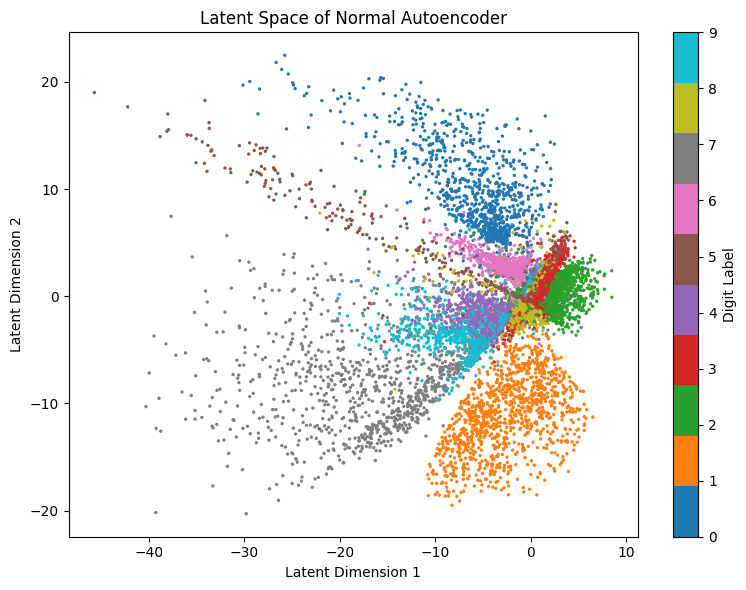

In [7]:
autoencoder.eval()

all_latents = []
all_labels  = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        _, latent = autoencoder(images)
        all_latents.append(latent.cpu().numpy())
        all_labels.append(labels.numpy())

all_latents = np.concatenate(all_latents, axis=0)
all_labels  = np.concatenate(all_labels,  axis=0)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    all_latents[:, 0],
    all_latents[:, 1],
    c=all_labels,
    cmap='tab10',
    s=2
)
plt.colorbar(scatter, label='Digit Label')
plt.title('Latent Space of Normal Autoencoder')
plt.xlabel('Latent Dimension 1')
plt.ylabel('Latent Dimension 2')
plt.tight_layout()
plt.show()

## Step 7: Variational Autoencoder (VAE) Architecture

Unlike a normal Autoencoder which maps input to a fixed point in latent space, a VAE maps input to a probability distribution (mean and log variance). During decoding, a sample is drawn from this distribution using the reparameterisation trick. This forces the latent space to be continuous and well organised.

In [8]:
class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU()
        )

        # Mean and log variance layers
        self.fc_mu      = nn.Linear(64, 2)
        self.fc_log_var = nn.Linear(64, 2)

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(2, 64),
            nn.ReLU(),
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Sigmoid()
        )

    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        x = x.view(-1, 784)

        # Encode
        h       = self.encoder(x)
        mu      = self.fc_mu(h)
        log_var = self.fc_log_var(h)

        # Sample from distribution
        z = self.reparameterize(mu, log_var)

        # Decode
        output = self.decoder(z)

        return output, mu, log_var


vae = VAE().to(device)
print(vae)

VAE(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=64, bias=True)
    (3): ReLU()
  )
  (fc_mu): Linear(in_features=64, out_features=2, bias=True)
  (fc_log_var): Linear(in_features=64, out_features=2, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=784, bias=True)
    (5): Sigmoid()
  )
)


## Step 8: VAE Loss Function (Reconstruction Loss + KL Divergence)

The VAE uses two loss functions combined together:
- Reconstruction Loss (MSE): measures how well the decoder reconstructed the original image
- KL Divergence: measures how far the learned distribution is from a standard normal distribution. This is what forces the latent space to be compact and organised.

In [9]:
def vae_loss(output, target, mu, log_var):

    # Reconstruction loss (MSE)
    target = target.view(-1, 784)
    reconstruction_loss = nn.functional.mse_loss(output, target, reduction='sum')

    # KL Divergence loss
    kl_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())

    # Total loss
    total_loss = reconstruction_loss + kl_loss

    return total_loss, reconstruction_loss, kl_loss

print("VAE loss function defined.")

VAE loss function defined.


## Step 9: Training the VAE for 20 Epochs

During training, both reconstruction loss and KL divergence loss are tracked separately along with the total loss.

In [10]:
vae_optimizer = optim.Adam(vae.parameters(), lr=0.001)

recon_losses = []
kl_losses    = []
total_losses = []

for epoch in range(1, 21):

    total_loss_epoch = 0
    recon_loss_epoch = 0
    kl_loss_epoch    = 0

    for images, _ in train_loader:
        images = images.to(device)

        output, mu, log_var = vae(images)

        total_loss, recon_loss, kl_loss = vae_loss(output, images, mu, log_var)

        vae_optimizer.zero_grad()
        total_loss.backward()
        vae_optimizer.step()

        total_loss_epoch += total_loss.item()
        recon_loss_epoch += recon_loss.item()
        kl_loss_epoch    += kl_loss.item()

    avg_total = total_loss_epoch / len(train_loader)
    avg_recon = recon_loss_epoch / len(train_loader)
    avg_kl    = kl_loss_epoch    / len(train_loader)

    total_losses.append(avg_total)
    recon_losses.append(avg_recon)
    kl_losses.append(avg_kl)

    print(f"Epoch [{epoch}/20]  Total Loss: {avg_total:.2f}  Reconstruction Loss: {avg_recon:.2f}  KL Loss: {avg_kl:.2f}")

Epoch [1/20]  Total Loss: 6530.09  Reconstruction Loss: 6277.89  KL Loss: 252.20
Epoch [2/20]  Total Loss: 5464.26  Reconstruction Loss: 5050.25  KL Loss: 414.01
Epoch [3/20]  Total Loss: 5253.13  Reconstruction Loss: 4792.83  KL Loss: 460.30
Epoch [4/20]  Total Loss: 5131.28  Reconstruction Loss: 4636.03  KL Loss: 495.25
Epoch [5/20]  Total Loss: 5031.90  Reconstruction Loss: 4510.32  KL Loss: 521.58
Epoch [6/20]  Total Loss: 4951.32  Reconstruction Loss: 4411.52  KL Loss: 539.79
Epoch [7/20]  Total Loss: 4887.83  Reconstruction Loss: 4326.73  KL Loss: 561.10
Epoch [8/20]  Total Loss: 4834.87  Reconstruction Loss: 4260.70  KL Loss: 574.17
Epoch [9/20]  Total Loss: 4787.09  Reconstruction Loss: 4202.22  KL Loss: 584.87
Epoch [10/20]  Total Loss: 4744.78  Reconstruction Loss: 4150.34  KL Loss: 594.44
Epoch [11/20]  Total Loss: 4716.08  Reconstruction Loss: 4111.97  KL Loss: 604.10
Epoch [12/20]  Total Loss: 4683.37  Reconstruction Loss: 4073.48  KL Loss: 609.89
Epoch [13/20]  Total Loss

## Step 10: Plotting the VAE Loss

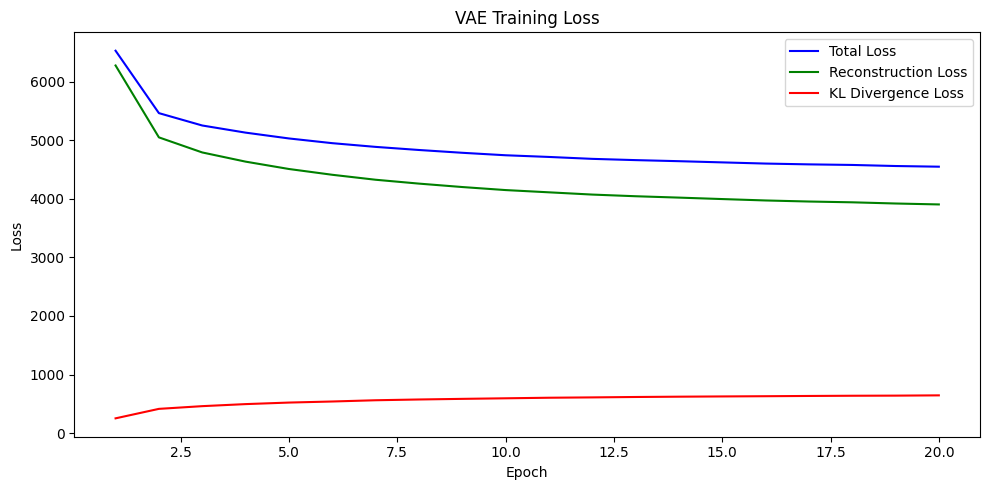

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, 21), total_losses, label='Total Loss',          color='blue')
plt.plot(range(1, 21), recon_losses, label='Reconstruction Loss', color='green')
plt.plot(range(1, 21), kl_losses,    label='KL Divergence Loss',  color='red')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('VAE Training Loss')
plt.legend()
plt.tight_layout()
plt.show()

## Step 11: Reconstruction Test Using VAE

Displaying original images on the top row and their VAE reconstructions on the bottom row.

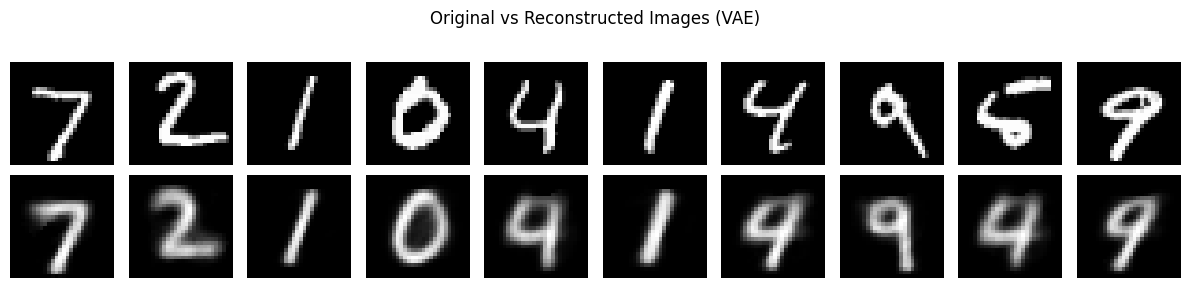

In [12]:
vae.eval()

test_images, _ = next(iter(test_loader))
test_images = test_images.to(device)

with torch.no_grad():
    reconstructed, _, _ = vae(test_images)

reconstructed = reconstructed.view(-1, 28, 28).cpu().numpy()
test_images   = test_images.cpu().squeeze().numpy()

plt.figure(figsize=(12, 3))
for i in range(10):

    # Original images - top row
    plt.subplot(2, 10, i + 1)
    plt.imshow(test_images[i], cmap='gray')
    plt.axis('off')
    if i == 0:
        plt.ylabel('Original', fontsize=9)

    # Reconstructed images - bottom row
    plt.subplot(2, 10, i + 11)
    plt.imshow(reconstructed[i], cmap='gray')
    plt.axis('off')
    if i == 0:
        plt.ylabel('Reconstructed', fontsize=9)

plt.suptitle('Original vs Reconstructed Images (VAE)')
plt.tight_layout()
plt.show()

## Step 12: Latent Space of the VAE

Passing all test images through the trained VAE encoder and plotting their 2D latent representations. Comparing this with the normal Autoencoder latent space from Step 6.

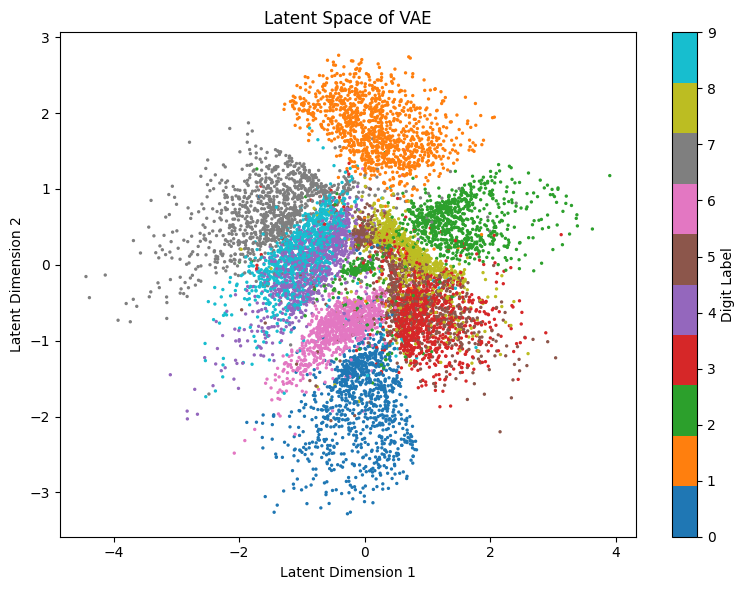

In [13]:
vae.eval()

vae_latents = []
vae_labels  = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        _, mu, _ = vae(images)
        vae_latents.append(mu.cpu().numpy())
        vae_labels.append(labels.numpy())

vae_latents = np.concatenate(vae_latents, axis=0)
vae_labels  = np.concatenate(vae_labels,  axis=0)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    vae_latents[:, 0],
    vae_latents[:, 1],
    c=vae_labels,
    cmap='tab10',
    s=2
)
plt.colorbar(scatter, label='Digit Label')
plt.title('Latent Space of VAE')
plt.xlabel('Latent Dimension 1')
plt.ylabel('Latent Dimension 2')
plt.tight_layout()
plt.show()

## Step 13: VAE Generated Digits Across Latent Space

Sampling points in a grid across the latent space (from -3 to +3) and decoding each point into an image. This shows how digits change as we move through the latent space.

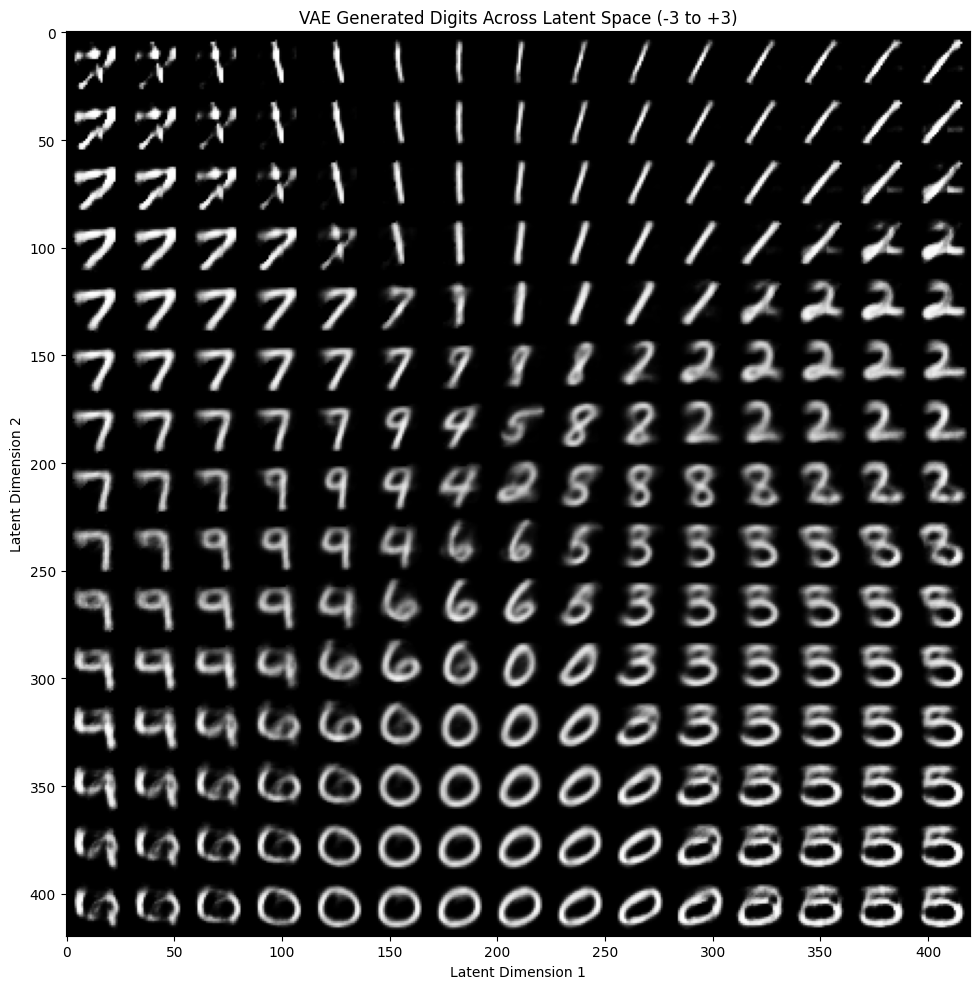

In [14]:
vae.eval()

n     = 15
limit = 3.0

grid_x = np.linspace(-limit, limit, n)
grid_y = np.linspace(-limit, limit, n)

figure = np.zeros((28 * n, 28 * n))

with torch.no_grad():
    for i, yi in enumerate(grid_y[::-1]):
        for j, xi in enumerate(grid_x):
            z_sample = torch.tensor([[xi, yi]], dtype=torch.float32).to(device)
            decoded  = vae.decoder(z_sample)
            digit    = decoded.cpu().numpy().reshape(28, 28)
            figure[i * 28:(i+1) * 28, j * 28:(j+1) * 28] = digit

plt.figure(figsize=(10, 10))
plt.imshow(figure, cmap='gray')
plt.title('VAE Generated Digits Across Latent Space (-3 to +3)')
plt.xlabel('Latent Dimension 1')
plt.ylabel('Latent Dimension 2')
plt.tight_layout()
plt.show()

## Step 14: Generated Images from Extreme Latent Points

Sampling points from the extreme corners and edges of the latent space (beyond ±3) and decoding them to see what the VAE generates at the boundaries.

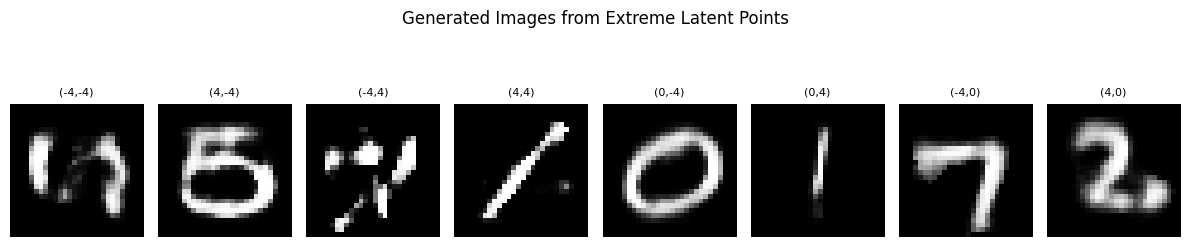

In [15]:
vae.eval()

extreme_points = [
    (-4, -4),
    ( 4, -4),
    (-4,  4),
    ( 4,  4),
    ( 0, -4),
    ( 0,  4),
    (-4,  0),
    ( 4,  0)
]

plt.figure(figsize=(12, 3))
for i, (x, y) in enumerate(extreme_points):
    z = torch.tensor([[x, y]], dtype=torch.float32).to(device)

    with torch.no_grad():
        decoded = vae.decoder(z)

    img = decoded.cpu().numpy().reshape(28, 28)

    plt.subplot(1, 8, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(f'({x},{y})', fontsize=8)
    plt.axis('off')

plt.suptitle('Generated Images from Extreme Latent Points')
plt.tight_layout()
plt.show()

## Step 15: Generating Image from a Point Outside the Latent Space

Taking a point far outside the learned latent space to observe what the VAE generates when given a completely unseen and out-of-distribution input.

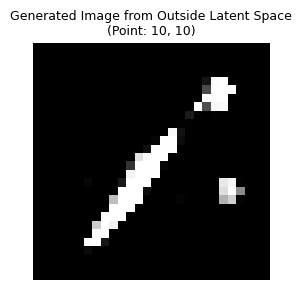

Min pixel value : 0.0000
Max pixel value : 1.0000
Mean pixel value: 0.0735


In [16]:
vae.eval()

outside_point = torch.tensor([[10.0, 10.0]], dtype=torch.float32).to(device)

with torch.no_grad():
    decoded = vae.decoder(outside_point)

img = decoded.cpu().numpy().reshape(28, 28)

plt.figure(figsize=(3, 3))
plt.imshow(img, cmap='gray')
plt.title('Generated Image from Outside Latent Space\n(Point: 10, 10)', fontsize=9)
plt.axis('off')
plt.tight_layout()
plt.show()

print(f"Min pixel value : {img.min():.4f}")
print(f"Max pixel value : {img.max():.4f}")
print(f"Mean pixel value: {img.mean():.4f}")

## Written Observations

### 1. Do similar digits form clusters?

Yes, similar digits clearly form clusters in the VAE latent space. Looking at the scatter plot from Step 12, each digit occupies its own distinct region, digit 0 (blue) sits at the bottom center, digit 1 (orange) at the top center, digit 7 (grey) towards the left, and digit 2 (green) towards the right. This is in sharp contrast to the normal Autoencoder latent space from Step 6, where clusters were spread across a range of -40 to +10 with no clear organisation.

### 2. Are the clusters clearly separated?

The clusters are not perfectly separated, there is some overlap especially in the center of the latent space where visually similar digits like 4, 9, 6 and 5 tend to mix. This makes sense because these digits share similar visual features (curves, loops). However the overall structure is much more organised than the normal Autoencoder. The KL divergence loss is responsible for this, it forces all clusters to stay close to the origin while still keeping them distinguishable from each other.

### 3. How do generated digits change when moving gradually through the latent space?

As seen in Step 13, the digits change smoothly and gradually as we move across the latent space grid. Moving from the top left to the bottom center, the images transition from 7s to 9s to 0s. Moving from left to right across the middle, we see transitions from 7 to 9 to 4 to 6 to 5 to 8 to 2. The changes happen step by step with no sudden jumps, intermediate images often look like a blend between two digits.

### 4. Does the transition between generated images appear smooth?

Yes, the transitions are smooth throughout the grid in Step 13. This is one of the key advantages of a VAE over a normal Autoencoder. Because the KL divergence loss forces the latent space to be continuous with no gaps, decoding any point between two digit clusters produces a meaningful intermediate image rather than noise. This property is what makes VAEs useful for generating new data, we can interpolate between any two points in the latent space and get a valid output.

### 5. Observation from Extreme and Outside Latent Points

From Step 14, points at the corners like (-4, 4) and (4, 4) produced distorted or unrecognisable images because those regions had little to no training data. However edge points like (0, -4) and (0, 4) still produced clean digits (0 and 1) because those directions align with actual digit clusters.

From Step 15, passing a completely out-of-distribution point (10, 10) produced a meaningless diagonal pattern with a mean pixel value of only 0.0735. This confirms that the VAE decoder only works